# Assignment 3

### Import data:
##### (Can take up to 10 min)

In [ ]:
import sklearn.datasets as datasets


d_train = datasets.fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

d_test = datasets.fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": d_train.data,
    "label": d_train.target
})

test_dataset = Dataset.from_dict({
    "text": d_test.data,
    "label": d_test.target
})

AttributeError: 

In [1]:
model_name = "prajjwal1/bert-tiny"

In [7]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": d_train.data,
    "label": d_train.target
})

test_dataset = Dataset.from_dict({
    "text": d_test.data,
    "label": d_test.target
})


C:\Users\Joseph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")


C:\Users\Joseph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Joseph\.cache\huggingface\hub\models--prajjwal1--bert-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 7532

In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=20
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
import transformers
print(transformers.__version__)


4.57.1


In [4]:
# pip install torch transformers datasets tqdm --upgrade
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from tqdm.auto import tqdm

model_name = "prajjwal1/bert-tiny"   # your chosen small model

# --- assume you already have HF datasets: train_dataset, test_dataset
# If not, recreate quickly:
from datasets import Dataset
import sklearn.datasets as skdatasets
d_train = skdatasets.fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'))
d_test  = skdatasets.fetch_20newsgroups(subset='test',  remove=('headers','footers','quotes'))
train_dataset = Dataset.from_dict({"text": [str(t) for t in d_train.data], "label": list(map(int,d_train.target))})
test_dataset  = Dataset.from_dict({"text": [str(t) for t in d_test.data],  "label": list(map(int,d_test.target))})

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding=False, max_length=256)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
test_dataset  = test_dataset.map(tokenize_fn, batched=True)

# Keep only needed columns
train_dataset = train_dataset.remove_columns(["text"]).with_format("pt")
test_dataset  = test_dataset.remove_columns(["text"]).with_format("pt")

# Collate function that uses tokenizer.pad to create padded tensors
def collate_fn(batch):
    # batch: list of dicts with input_ids (torch.Tensor), attention_mask (torch.Tensor), label (int tensor)
    encodings = [{"input_ids": item["input_ids"], "attention_mask": item["attention_mask"]} for item in batch]
    padded = tokenizer.pad(encodings, return_tensors="pt")
    labels = torch.tensor([int(item["label"]) for item in batch], dtype=torch.long)
    return padded, labels

# DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
eval_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Model, device, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=20).to(device)
#optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
# optional simple scheduler
total_steps = len(train_loader) * 2  # if 2 epochs
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=total_steps)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, desc=f"train epoch {epoch+1}")
    running_loss = 0.0
    for batch_inputs, labels in loop:
        # move to device
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
        labels = labels.to(device)

        outputs = model(**batch_inputs, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    # simple evaluation at end of epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_inputs, labels in tqdm(eval_loader, desc="eval"):
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
            labels = labels.to(device)
            logits = model(**batch_inputs).logits
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1} eval accuracy: {acc:.4f}")

# Save the model
model.save_pretrained("./tinybert-20news-pytorch")
tokenizer.save_pretrained("./tinybert-20news-pytorch")

print("Done. Model saved to ./tinybert-20news-pytorch")


Map: 100%|██████████| 7532/7532 [00:01<00:00, 3923.09 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
eval: 100%|██████████| 471/471 [01:29<00:00,  5.29it/s]


Epoch 1 eval accuracy: 0.6087


eval: 100%|██████████| 471/471 [00:52<00:00,  9.02it/s]


Epoch 2 eval accuracy: 0.6468


eval: 100%|██████████| 471/471 [02:13<00:00,  3.53it/s]


Epoch 3 eval accuracy: 0.6543


eval: 100%|██████████| 471/471 [02:42<00:00,  2.90it/s]


Epoch 4 eval accuracy: 0.6583


train epoch 5:  15%|█▍        | 106/708 [01:25<08:04,  1.24it/s, loss=0.834]


KeyboardInterrupt: 

In [5]:
 # ---- imports ----
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import sklearn.datasets as skdatasets
from tqdm.auto import tqdm

# ---- load data ----
d_train = skdatasets.fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'))
d_test  = skdatasets.fetch_20newsgroups(subset='test',  remove=('headers','footers','quotes'))

train_dataset = Dataset.from_dict({"text": [str(t) for t in d_train.data], "label": list(map(int,d_train.target))})
test_dataset  = Dataset.from_dict({"text": [str(t) for t in d_test.data],  "label": list(map(int,d_test.target))})

# ---- tokenizer ----
model_name = "prajjwal1/bert-tiny"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=256)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
test_dataset  = test_dataset.map(tokenize_fn, batched=True)

# Keep only needed columns
train_dataset = train_dataset.remove_columns(["text"]).with_format("pt")
test_dataset  = test_dataset.remove_columns(["text"]).with_format("pt")

# ---- collate function ----
def collate_fn(batch):
    encodings = [{"input_ids": item["input_ids"], "attention_mask": item["attention_mask"]} for item in batch]
    padded = tokenizer.pad(encodings, return_tensors="pt")
    labels = torch.tensor([int(item["label"]) for item in batch], dtype=torch.long)
    return padded, labels

# ---- dataloaders ----
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
eval_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# ---- model, device, optimizer, scheduler ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=20).to(device)

epochs = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
total_steps = len(train_loader) * epochs
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=total_steps)

# ---- training loop ----
for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, desc=f"Train epoch {epoch+1}")
    running_loss = 0.0
    for batch_inputs, labels in loop:
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
        labels = labels.to(device)

        outputs = model(**batch_inputs, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    # ---- evaluation after epoch ----
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_inputs, labels in tqdm(eval_loader, desc="Eval"):
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
            labels = labels.to(device)
            logits = model(**batch_inputs).logits
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1} eval accuracy: {acc:.4f}")

# ---- save model ----
model.save_pretrained("./tinybert-20news-pytorch")
tokenizer.save_pretrained("./tinybert-20news-pytorch")
print("Done. Model saved to ./tinybert-20news-pytorch")


Map: 100%|██████████| 7532/7532 [00:02<00:00, 3035.55 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Eval: 100%|██████████| 471/471 [00:52<00:00,  8.93it/s]


Epoch 1 eval accuracy: 0.6025


Eval: 100%|██████████| 471/471 [00:53<00:00,  8.87it/s]


Epoch 2 eval accuracy: 0.6462


Eval: 100%|██████████| 471/471 [00:58<00:00,  8.05it/s]


Epoch 3 eval accuracy: 0.6587


Eval: 100%|██████████| 471/471 [01:00<00:00,  7.83it/s]


Epoch 4 eval accuracy: 0.6585


Train epoch 5:   9%|▉         | 63/708 [00:26<04:29,  2.40it/s, loss=0.295]


KeyboardInterrupt: 

In [6]:
# Full training script: warmup + cosine LR + early stopping
# Requirements: transformers, datasets, torch, scikit-learn, tqdm
# pip install transformers datasets torch scikit-learn tqdm

import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from datasets import Dataset
import sklearn.datasets as skdatasets
from tqdm.auto import tqdm
import numpy as np
import os

# -------------------------
# Config
# -------------------------
model_name = "prajjwal1/bert-tiny"
num_labels = 20
batch_size = 16
epochs = 10                # max epochs (early stopping will likely stop earlier)
initial_lr = 2e-4
warmup_ratio = 0.05        # fraction of total steps used for linear warmup
patience = 2               # early stopping patience (in epochs)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = "./tinybert-warmup-cosine"
os.makedirs(save_dir, exist_ok=True)

# -------------------------
# Load data & make HF Datasets
# -------------------------
d_train = skdatasets.fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'))
d_test  = skdatasets.fetch_20newsgroups(subset='test',  remove=('headers','footers','quotes'))

train_dataset = Dataset.from_dict({
    "text": [str(t) for t in d_train.data],
    "label": list(map(int, d_train.target))
})
test_dataset = Dataset.from_dict({
    "text": [str(t) for t in d_test.data],
    "label": list(map(int, d_test.target))
})

# -------------------------
# Tokenizer + tokenization
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=256)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
test_dataset  = test_dataset.map(tokenize_fn, batched=True)

train_dataset = train_dataset.remove_columns(["text"]).with_format("pt")
test_dataset  = test_dataset.remove_columns(["text"]).with_format("pt")

# -------------------------
# Collate function (auto-pad)
# -------------------------
def collate_fn(batch):
    encodings = [{"input_ids": item["input_ids"], "attention_mask": item["attention_mask"]} for item in batch]
    padded = tokenizer.pad(encodings, return_tensors="pt")
    labels = torch.tensor([int(item["label"]) for item in batch], dtype=torch.long)
    return padded, labels

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
eval_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# -------------------------
# Model, optimizer, scheduler
# -------------------------
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=initial_lr)

# total training steps
total_steps = len(train_loader) * epochs
num_warmup_steps = int(total_steps * warmup_ratio)

# get_scheduler from transformers: supports "cosine"
scheduler = get_scheduler(
    name="cosine",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

# -------------------------
# Early stopping setup
# -------------------------
best_val_acc = 0.0
epochs_since_improve = 0
best_epoch = -1

# -------------------------
# Training loop
# -------------------------
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    progress = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{epochs}", leave=False)
    for batch_inputs, labels in progress:
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
        labels = labels.to(device)

        outputs = model(**batch_inputs, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()        # step scheduler each optimizer step
        optimizer.zero_grad()

        train_loss += loss.item()
        progress.set_postfix(loss=train_loss / (progress.n + 1))

    avg_train_loss = train_loss / len(train_loader)
    # -------------------------
    # Evaluation
    # -------------------------
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0
    with torch.no_grad():
        for batch_inputs, labels in tqdm(eval_loader, desc=f"[Eval] Epoch {epoch}", leave=False):
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
            labels = labels.to(device)
            outputs = model(**batch_inputs, labels=labels)
            logits = outputs.logits
            loss = outputs.loss

            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            eval_loss += loss.item()

    val_acc = correct / total
    avg_eval_loss = eval_loss / len(eval_loader)
    print(f"Epoch {epoch} summary -> train_loss: {avg_train_loss:.4f}, val_loss: {avg_eval_loss:.4f}, val_acc: {val_acc:.4f}")

    # -------------------------
    # Early stopping check
    # -------------------------
    if val_acc > best_val_acc + 1e-6:   # small epsilon to avoid float noise
        best_val_acc = val_acc
        epochs_since_improve = 0
        best_epoch = epoch
        # save best model
        model.save_pretrained(os.path.join(save_dir, "best"))
        tokenizer.save_pretrained(os.path.join(save_dir, "best"))
        print(f"  New best val_acc: {best_val_acc:.4f} (saved)")
    else:
        epochs_since_improve += 1
        print(f"  No improvement for {epochs_since_improve} epoch(s).")

    if epochs_since_improve >= patience:
        print(f"Early stopping triggered (no improvement for {patience} epochs).")
        break

# -------------------------
# Final evaluation on test set using best model (if saved)
# -------------------------
# load best if available
best_path = os.path.join(save_dir, "best")
if os.path.isdir(best_path):
    best_model = AutoModelForSequenceClassification.from_pretrained(best_path).to(device)
    best_tokenizer = AutoTokenizer.from_pretrained(best_path)
else:
    best_model = model
    best_tokenizer = tokenizer

best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_inputs, labels in tqdm(eval_loader, desc="Final test eval"):
        # if tokenizer changed (same here), collate uses tokenizer.pad so batch_inputs keys are fine
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
        labels = labels.to(device)
        logits = best_model(**batch_inputs).logits
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

final_acc = correct / total
print(f"Final test accuracy (best model): {final_acc:.4f}")
print(f"Best epoch: {best_epoch}, Best validation accuracy: {best_val_acc:.4f}")

# -------------------------
# Save last checkpoint as fallback
# -------------------------
model.save_pretrained(os.path.join(save_dir, "last"))
tokenizer.save_pretrained(os.path.join(save_dir, "last"))
print(f"Saved last checkpoint to {os.path.join(save_dir, 'last')}")


Map: 100%|██████████| 7532/7532 [00:02<00:00, 3052.40 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[Train] Epoch 1/10:   0%|          | 0/708 [00:00<?, ?it/s]You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch 1 summary -> train_loss: 2.2986, val_loss: 1.4972, val_acc: 0.5843
  New best val_acc: 0.5843 (saved)


Epoch 2 summary -> train_loss: 1.1681, val_loss: 1.1972, val_acc: 0.6525
  New best val_acc: 0.6525 (saved)


Epoch 3 summary -> train_loss: 0.7195, val_loss: 1.1728, val_acc: 0.6664
  New best val_acc: 0.6664 (saved)


Epoch 4 summary -> train_loss: 0.4547, val_loss: 1.2479, val_acc: 0.6648
  No improvement for 1 epoch(s).


KeyboardInterrupt: 

In [15]:
# test_tinybert.py
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, classification_report
import string

# -------------------------------
# 1️⃣ Load saved TinyBERT model
# -------------------------------
model_path = "./tinybert-20news-pytorch"  # change if needed
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = 0 if torch.cuda.is_available() else -1
bert_pipe = TextClassificationPipeline(model=model, tokenizer=tokenizer, device=device)

# -------------------------------
# 2️⃣ Load test data
# -------------------------------
d_test = fetch_20newsgroups(subset='test', remove=('headers','footers','quotes'))
X_test = d_test.data
y_test = d_test.target
# -------------------------------
# 3️⃣ Preprocess + truncate test data
# -------------------------------
translator = str.maketrans('', '', string.punctuation)

def preprocess_doc(doc):
    txt = doc.replace('\n', ' ')
    txt = txt.translate(translator)
    words = txt.split()
    words = [w.lower() for w in words if len(w) > 2]
    return ' '.join(words)

X_test_clean = [preprocess_doc(d) for d in X_test]

# Truncate each document to max 510 tokens (leave 2 for special tokens)
max_tokens = 510
X_test_trunc = []
for doc in X_test_clean:
    tokens = doc.split()
    if len(tokens) > max_tokens:
        tokens = tokens[:max_tokens]
    X_test_trunc.append(" ".join(tokens))

# -------------------------------
# 4️⃣ Predict
# -------------------------------
y_pred = []
for text in X_test_trunc:
    out = bert_pipe(text, truncation=True, max_length=512)  # important!
    label = int(out[0]['label'].split("_")[1])
    y_pred.append(label)

# -------------------------------
# 5️⃣ Evaluate
# -------------------------------
from sklearn.metrics import accuracy_score, classification_report
y_test = fetch_20newsgroups(subset='test', remove=('headers','footers','quotes')).target
print("TinyBERT Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Device set to use cpu


TinyBERT Test accuracy: 0.3033722782793415
              precision    recall  f1-score   support

           0       0.34      0.42      0.37       319
           1       0.22      0.39      0.28       389
           2       0.00      0.00      0.00       394
           3       0.25      0.03      0.06       392
           4       0.16      0.03      0.04       385
           5       0.34      0.41      0.37       395
           6       0.20      0.79      0.31       390
           7       0.26      0.32      0.28       396
           8       0.41      0.37      0.39       398
           9       0.49      0.55      0.52       397
          10       0.50      0.42      0.46       399
          11       0.22      0.01      0.01       396
          12       0.12      0.15      0.13       393
          13       0.81      0.35      0.49       396
          14       0.65      0.39      0.49       394
          15       0.56      0.34      0.42       398
          16       0.21      0.09     

##### Remove \n

Loading 20 Newsgroups dataset...
Train size: 11314, Test size: 7532
Preprocessing train texts (this can take a moment)...
Train split: 9051 examples, Val split: 2263 examples
Starting GridSearchCV (this may take several minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Grid search results ===
Best CV score: 0.7127380556513144
Best params: {'clf__C': 2.0, 'vec__char__ngram_range': (3, 5), 'vec__word__max_features': 20000, 'vec__word__ngram_range': (1, 1)}

Validation accuracy: 0.7238
              precision    recall  f1-score   support

           0     0.6889    0.6458    0.6667        96
           1     0.7000    0.7179    0.7089       117
           2     0.6909    0.6441    0.6667       118
           3     0.6098    0.6356    0.6224       118
           4     0.7429    0.6783    0.7091       115
           5     0.7946    0.7479    0.7706       119
           6     0.7339    0.6838    0.7080       117
           7     0.7297    0.6807    0.7043       

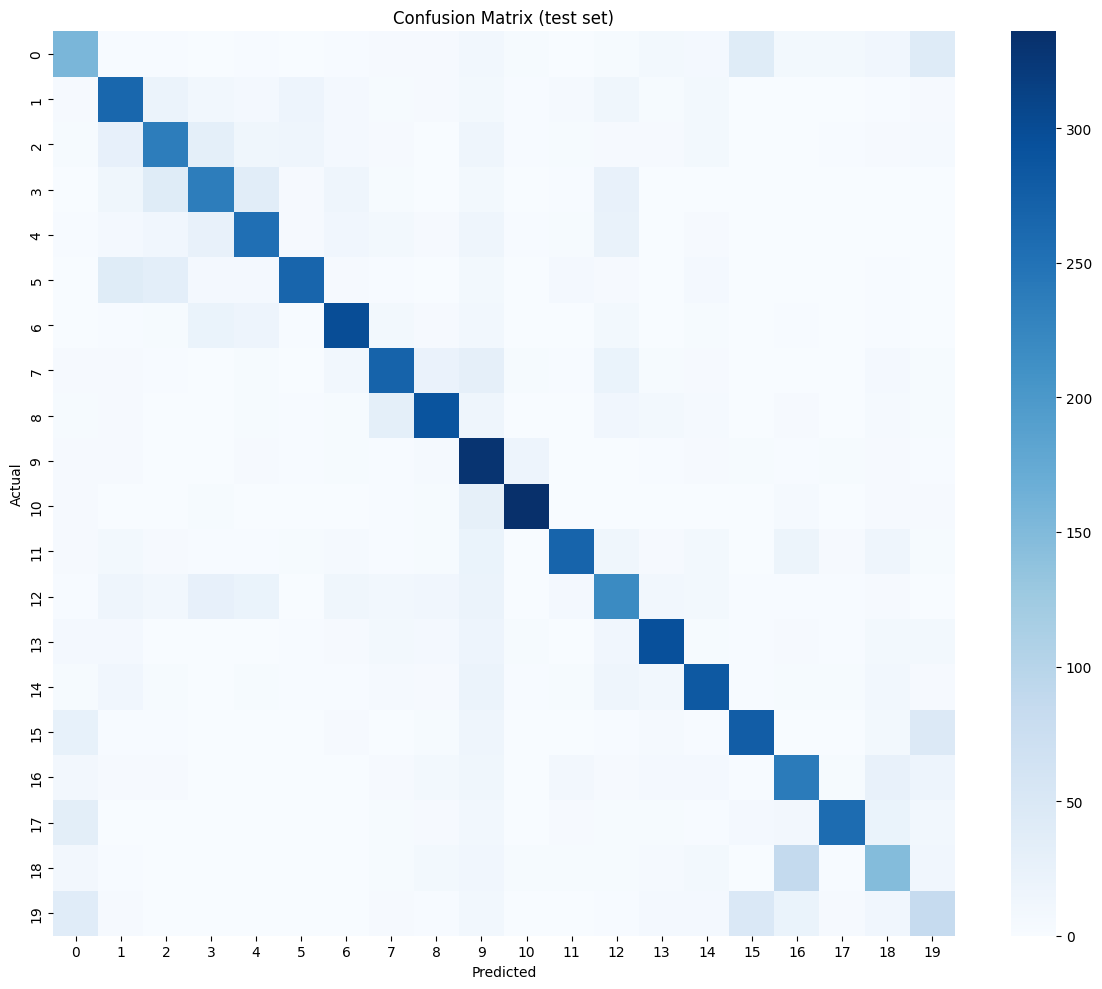

Saved best model to best_tfidf_logreg_joblib.joblib


In [7]:
# Colab-ready: improved sklearn pipeline (Option A)
# Copy/paste into a fresh Colab cell and run

# --- installs (Colab often already has these; harmless to run) ---

# --- imports ---
import re, string
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from joblib import dump

# --- config ---
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_JOBS = -1           # set to -1 to use all CPUs (Colab has multiple cores)
VERBOSE = 2

# --- load dataset ---
print("Loading 20 Newsgroups dataset...")
#d_train = fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'))
#d_test  = fetch_20newsgroups(subset='test',  remove=('headers','footers','quotes'))
print(f"Train size: {len(d_train.data)}, Test size: {len(d_test.data)}")

# --- preprocessing ---
translator = str.maketrans('', '', string.punctuation)
stop_words = set(stopwords.words('english'))

def preprocess(doc):
    # minimal cleaning: remove newlines, punctuation, lower, collapse spaces, remove digits & short tokens
    txt = doc.replace('\n', ' ').translate(translator).lower()
    txt = re.sub(r'\s+', ' ', txt).strip()
    # optionally remove tokens with digits and very short tokens
    tokens = [w for w in txt.split() if not re.search(r'\d', w) and len(w) > 2]
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

print("Preprocessing train texts (this can take a moment)...")
raw_texts = [preprocess(t) for t in d_train.data]
raw_texts_test = [preprocess(t) for t in d_test.data]
labels = list(d_train.target)
labels_test = list(d_test.target)

# --- train/validation split (stratified) ---
X_train, X_val, y_train, y_val = train_test_split(
    raw_texts, labels, test_size=TEST_SIZE, stratify=labels, random_state=RANDOM_STATE
)
print(f"Train split: {len(X_train)} examples, Val split: {len(X_val)} examples")

# --- vectorizers: word ngrams + char ngrams ---
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1,2),   # unigrams + bigrams
    max_features=30000,
    min_df=3,
    max_df=0.9
)
char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),   # char-level ngrams
    max_features=20000,
    min_df=5
)

vectorizer = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])

# --- pipeline: vectorizer + classifier ---
pipeline = Pipeline([
    ('vec', vectorizer),
    ('clf', LogisticRegression(
        solver='saga',        # works well with large sparse features and supports l1/l2
        penalty='l2',
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# --- grid to search (keeps size manageable on Colab) ---
param_grid = {
    'vec__word__ngram_range': [(1,1), (1,2)],
    'vec__word__max_features': [20000, 30000],
    'vec__char__ngram_range': [(3,5), (4,6)],
    'clf__C': [0.5, 1.0, 2.0]
}

print("Starting GridSearchCV (this may take several minutes)...")
grid = GridSearchCV(pipeline, param_grid=param_grid, cv=CV_FOLDS, n_jobs=N_JOBS, verbose=VERBOSE)
grid.fit(X_train, y_train)

print("\n=== Grid search results ===")
print("Best CV score:", grid.best_score_)
print("Best params:", grid.best_params_)

# --- evaluate on validation split ---
y_val_pred = grid.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation accuracy: {val_acc:.4f}")
print(classification_report(y_val, y_val_pred, digits=4))

# --- retrain best estimator on train+val (for final test evaluation) ---
best = grid.best_estimator_
X_train_val = X_train + X_val
y_train_val = y_train + y_val
print("Retraining best estimator on train+val (this may take a bit)...")
best.fit(X_train_val, y_train_val)

# --- evaluate on official test set ---
y_test_pred = best.predict(raw_texts_test)
test_acc = accuracy_score(labels_test, y_test_pred)
print(f"\nOfficial test accuracy: {test_acc:.4f}")
print(classification_report(labels_test, y_test_pred, digits=4))

# --- confusion matrix (test) ---
cm = confusion_matrix(labels_test, y_test_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', annot=False)
plt.title('Confusion Matrix (test set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- save the best model ---
dump(best, "best_tfidf_logreg_joblib.joblib")
print("Saved best model to best_tfidf_logreg_joblib.joblib")


In [17]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Using CPU.")


No GPU detected. Using CPU.


In [12]:
# improved_option_a.py
"""
Improved Option A: TF-IDF + LinearSVC for 20 Newsgroups text classification
"""

import re
import string
import joblib
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# 1️⃣ Load the 20 Newsgroups dataset
# -------------------------------
categories = None  # None = all categories
remove_parts = ('headers', 'footers', 'quotes')

#d_train = fetch_20newsgroups(subset='train', categories=categories, remove=remove_parts)
#d_test  = fetch_20newsgroups(subset='test',  categories=categories, remove=remove_parts)

X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    d_train.data, d_train.target, test_size=0.2, stratify=d_train.target, random_state=42
)

X_test_texts = d_test.data
y_test = d_test.target

# -------------------------------
# 2️⃣ Preprocessing function
# -------------------------------
translator = str.maketrans('', '', string.punctuation)
stop_words = set()  # optionally import stopwords or keep empty

def preprocess_doc(doc):
    txt = doc.replace('\n', ' ')
    txt = txt.translate(translator)
    words = txt.split()
    words = [w.lower() for w in words if len(w) > 2]  # remove very short words
    # optionally remove stopwords if you have a set
    # words = [w for w in words if w not in stop_words]
    return ' '.join(words)

X_train_clean = [preprocess_doc(d) for d in X_train_texts]
X_val_clean   = [preprocess_doc(d) for d in X_val_texts]
X_test_clean  = [preprocess_doc(d) for d in X_test_texts]

# -------------------------------
# 3️⃣ TF-IDF Vectorization
# -------------------------------
vectorizer = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train_clean + X_val_clean)
y_train_full = list(y_train) + list(y_val)

X_test_vec = vectorizer.transform(X_test_clean)

# -------------------------------
# 4️⃣ Train LinearSVC
# -------------------------------
model = LinearSVC(C=1.2, max_iter=10000)
model.fit(X_train_vec, y_train_full)

# -------------------------------
# 5️⃣ Evaluate on validation set
# -------------------------------
X_val_vec = vectorizer.transform(X_val_clean)
y_val_pred = model.predict(X_val_vec)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# -------------------------------
# 6️⃣ Evaluate on test set
# -------------------------------
y_test_pred = model.predict(X_test_vec)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# -------------------------------
# 7️⃣ Save model + vectorizer
# -------------------------------
joblib.dump((vectorizer, model), "option_a_tfidf_model.joblib")
print("Saved Option A model and vectorizer to option_a_tfidf_model.joblib")


Validation accuracy: 0.9606716747680071
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        96
           1       0.98      0.92      0.95       117
           2       0.98      0.93      0.96       118
           3       0.97      0.96      0.97       118
           4       0.99      0.93      0.96       115
           5       0.99      0.99      0.99       119
           6       0.98      0.97      0.98       117
           7       0.99      0.97      0.98       119
           8       1.00      0.99      1.00       120
           9       0.63      1.00      0.77       119
          10       1.00      0.97      0.99       120
          11       1.00      0.97      0.98       119
          12       0.99      0.97      0.98       118
          13       1.00      0.97      0.98       119
          14       0.99      0.96      0.97       119
          15       0.98      0.97      0.97       120
          16       0.99      0.98      0.

In [16]:
# test_option_a.py
import joblib
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_20newsgroups
import string

# -------------------------------
# 1️⃣ Load saved model + vectorizer
# -------------------------------
vectorizer, model = joblib.load("best_tfidf_logreg_joblib.joblib")

# -------------------------------
# 2️⃣ Load test data
# -------------------------------
d_test = fetch_20newsgroups(subset='test', remove=('headers','footers','quotes'))
X_test_texts = d_test.data
y_test = d_test.target

# -------------------------------
# 3️⃣ Preprocess test data
# -------------------------------
translator = str.maketrans('', '', string.punctuation)

def preprocess_doc(doc):
    txt = doc.replace('\n', ' ')
    txt = txt.translate(translator)
    words = txt.split()
    words = [w.lower() for w in words if len(w) > 2]
    return ' '.join(words)

X_test_clean = [preprocess_doc(d) for d in X_test_texts]

# -------------------------------
# 4️⃣ Vectorize and predict
# -------------------------------
X_test_vec = vectorizer.transform(X_test_clean)
y_test_pred = model.predict(X_test_vec)

# -------------------------------
# 5️⃣ Evaluate
# -------------------------------
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


Test accuracy: 0.6675517790759427
              precision    recall  f1-score   support

           0       0.46      0.53      0.49       319
           1       0.62      0.70      0.66       389
           2       0.64      0.60      0.62       394
           3       0.61      0.62      0.62       392
           4       0.72      0.63      0.67       385
           5       0.85      0.66      0.74       395
           6       0.78      0.76      0.77       390
           7       0.70      0.68      0.69       396
           8       0.71      0.76      0.73       398
           9       0.52      0.84      0.64       397
          10       0.87      0.85      0.86       399
          11       0.89      0.66      0.76       396
          12       0.55      0.57      0.56       393
          13       0.76      0.75      0.75       396
          14       0.75      0.71      0.73       394
          15       0.73      0.66      0.70       398
          16       0.59      0.63      0.61    

In [3]:
import string
import re
from stop_words import get_stop_words

stop_words = set(get_stop_words('en'))
translator = str.maketrans('', '', string.punctuation)

data = []

for i in range(len(d_train.data)):
    text = d_train.data[i].replace('\n', ' ')
    text = text.translate(translator)
    text = text.split()
    text = [word for word in text if not re.search(r'\d', word)]
    text = [word for word in text if word.lower() not in stop_words]
    text = ' '.join(text).lower()
    data.append([d_train.target[i], text])

In [4]:
from collections import Counter
if(isinstance(data[0][1], str)):
    for i in range(len(data)):
        words = data[i][1].split()
        word_counts = Counter(words)
        data[i][1] = list(word_counts.items())

In [5]:
with open('keywords769.txt', 'r', encoding='utf-8') as f:
    keywords = [line.strip() for line in f if line.strip()]
keyword_set = set(keywords)
# Display the keyword_set contents (uses existing variable)
print(keyword_set)

{'pitching', 'different', 'fax', 'spiritual', 'standard', 'cable', 'blues', 'wings', 'military', 'history', 'motherboard', 'write', 'launch', 'therefore', 'space', 'program', 'yet', 'truth', 'churches', 'firearm', 'size', 'empire', 'nature', 'reason', 'mission', 'question', 'display', 'area', 'wolverine', 'xlib', 'controller', 'believe', 'wiretap', 'state', 'oil', 'waco', 'cubs', 'lot', 'goal', 'escrow', 'clinical', 'multiple', 'water', 'medical', 'chip', 'drives', 'know', 'published', 'come', 'played', 'newsletter', 'win', 'three', 'perhaps', 'village', 'look', 'processing', 'grace', 'speed', 'jobs', 'missions', 'bikes', 'mary', 'working', 'block', 'acts', 'cpu', 'things', 'small', 'problems', 'fans', 'book', 'soon', 'communications', 'drug', 'mail', 'manager', 'sale', 'includes', 'population', 'sell', 'clipper', 'players', 'bus', 'resources', 'tell', 'games', 'helmet', 'man', 'running', 'create', 'colormap', 'condition', 'eternal', 'even', 'saw', 'came', 'since', 'spacecraft', 'subje

### Model 1

In [6]:
y = []
samples = []
for i in range(len(data)):
    y.append(data[i][0])
    samples.append(data[i][1])

X_raw = []
for sample in samples:  # sample is list of (word, count) pairs
    d = dict(sample)
    d_lower = {k.lower(): v for k, v in d.items()}
    row = {kw: d_lower.get(kw, 0) for kw in keyword_set}
    X_raw.append(row)
from sklearn.feature_extraction import DictVectorizer

# Vectorize features
vectorizer = DictVectorizer(sparse=True)
X = vectorizer.fit_transform(X_raw)
from sklearn.linear_model import LogisticRegression

In [49]:
from sklearn.feature_extraction import DictVectorizer

# Vectorize features
vectorizer = DictVectorizer(sparse=True)
X = vectorizer.fit_transform(X_raw)

In [ ]:
# run the bigger grid search you prepared (this may take a while)
# use the GridSearchCV instance named `grid` defined earlier

# ensure X_train_texts and X_val_texts exist
from tkinter import Grid
from sklearn.base import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from transformers import pipeline


try:
    X_train_texts, X_val_texts, y_train, y_val
except NameError:
    raw_texts = [' '.join([w for w, c in sample]) for sample in samples]
    X_train_texts, X_val_texts, y_train, y_val = train_test_split(
        raw_texts, y, test_size=0.20, stratify=y, random_state=42
    )

# ensure GridSearchCV instance exists (use existing pipeline/param_grid if present)
try:
    Grid
except NameError:
    grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid.fit(X_train_texts, y_train)
print("Best CV score:", grid.best_score_)
print("Best params:", grid.best_params_)

# evaluate on validation split
y_val_pred = grid.predict(X_val_texts)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# retrain best estimator on train+val and evaluate official test set
best = grid.best_estimator_
best.fit(X_train_texts + X_val_texts, y_train + y_val)

# ensure y_test and raw_texts_test exist
try:
    y_test
except NameError:
    y_test = list(d_test.target)

try:
    raw_texts_test
except NameError:
    def preprocess_doc(doc):
        txt = doc.replace('\n', ' ')
        txt = txt.translate(translator)
        words = txt.split()
        words = [w for w in words if not re.search(r'\d', w)]
        words = [w.lower() for w in words if w.lower() not in stop_words]
        return ' '.join(words)
    raw_texts_test = [preprocess_doc(d) for d in d_test.data]

y_test_pred = best.predict(raw_texts_test)
print("Official test accuracy (best on train+val):", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best CV score: 0.7251124649548035
Best params: {'clf__alpha': 0.0001, 'clf__max_iter': 1000}
Validation accuracy: 0.7432611577551922
              precision    recall  f1-score   support

           0       0.76      0.65      0.70        96
           1       0.68      0.67      0.68       117
           2       0.71      0.65      0.68       118
           3       0.65      0.61      0.63       118
           4       0.73      0.71      0.72       115
           5       0.77      0.76      0.77       119
           6       0.77      0.75      0.76       117
           7       0.50      0.81      0.62       119
           8       0.77      0.74      0.75       120
           9       0.85      0.84      0.85       119
          10       0.87      0.88      0.88       120
          11       0.84      0.77      0.81       119
          12       0.73      0.74      0.73       118
          13       0.84      0.86      0.85       

In [ ]:
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ---- define stopwords and translator if not already defined ----
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
translator = str.maketrans('', '', string.punctuation)

# ---- preprocessing function ----
def preprocess_doc(doc):
    txt = doc.replace('\n', ' ').translate(translator)
    words = [w.lower() for w in txt.split() if len(w) > 2 and not re.search(r'\d', w)]
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

# ---- prepare train/validation split ----
if 'X_train_texts' not in locals() or 'X_val_texts' not in locals():
    raw_texts = [preprocess_doc(d) for d in d_train.data]
    X_train_texts, X_val_texts, y_train, y_val = train_test_split(
        raw_texts, list(d_train.target), test_size=0.20, stratify=d_train.target, random_state=42
    )

# ---- define pipeline ----
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# ---- define grid search ----
param_grid = {
    'vectorizer__max_features': [20000, 30000],
    'vectorizer__ngram_range': [(1,1), (1,2)],
    'classifier__C': [0.5, 1.0, 2.0]
}

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# ---- fit grid search on training data ----
grid.fit(X_train_texts, y_train)
print(f"Best CV score: {grid.best_score_:.4f}")
print("Best params:", grid.best_params_)

# ---- evaluate on validation split ----
y_val_pred = grid.predict(X_val_texts)
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(classification_report(y_val, y_val_pred))

# ---- retrain best estimator on train+val ----
best = grid.best_estimator_
X_train_val = X_train_texts + X_val_texts
y_train_val = y_train + y_val
best.fit(X_train_val, y_train_val)

# ---- prepare test data ----
if 'raw_texts_test' not in locals():
    raw_texts_test = [preprocess_doc(d) for d in d_test.data]
y_test = list(d_test.target)

# ---- evaluate on test set ----
y_test_pred = best.predict(raw_texts_test)
print(f"Official test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(classification_report(y_test, y_test_pred))
